# Filling missing data by random  variable

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [24]:
data = pd.read_csv('../../datasets/titanic_toy.csv')

In [5]:
data.head(5)

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [6]:
data.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [7]:
x = data.drop(columns=['Survived'])
y = data['Survived']

In [8]:
x.head(5)

,Age,Fare,Family
0,22.0,7.2500,1
1,38.0,71.2833,1
2,26.0,7.9250,0
3,35.0,53.1000,1
4,35.0,8.0500,0


In [10]:
y.head(5)

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [25]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [12]:
x_train.head(5)

,Age,Fare,Family
445,4.0,81.8583,2
650,NaN,7.8958,0
172,1.0,11.1333,2
450,36.0,27.7500,3
314,43.0,26.2500,2


In [13]:
y_train.head(5)

445    1
650    0
172    1
450    0
314    0
Name: Survived, dtype: int64

In [15]:
# filling age missing values with 99 and -1 
x_train['age_99'] = x_train['Age'].fillna(99)
x_train['age_minus1'] = x_train['Age'].fillna(-1)

# filling missing values fare 
x_train['fare_99'] = x_train['Fare'].fillna(99)
x_train['fare_minus1'] = x_train['Fare'].fillna(-1)

In [16]:
# Variance of age
print('The variance of the actual age is : ',x_train['Age'].var())
print('Variance of the feature when missing values of the age is filled with age 99 : ',x_train['age_99'].var())
print('Variance of the feature when missing values of the age is filled with age 99 : ',x_train['age_minus1'].var())

# variance of fare
print('The variance of the actual fare is : ',x_train['Fare'].var())
print('Variance of the feature when missing values of the fare is filled with fare 99 : ',x_train['fare_99'].var())
print('Variance of the feature when missing values of the fare is filled with fare 99 : ',x_train['fare_minus1'].var())

The variance of the actual age is :  211.9518806464334
Variance of the feature when missing values of the age is filled with age 99 :  946.397459304372
Variance of the feature when missing values of the age is filled with age 99 :  315.8741022466749
The variance of the actual fare is :  2666.9296723129737
Variance of the feature when missing values of the fare is filled with fare 99 :  2745.6273642718534
Variance of the feature when missing values of the fare is filled with fare 99 :  2587.685351503019


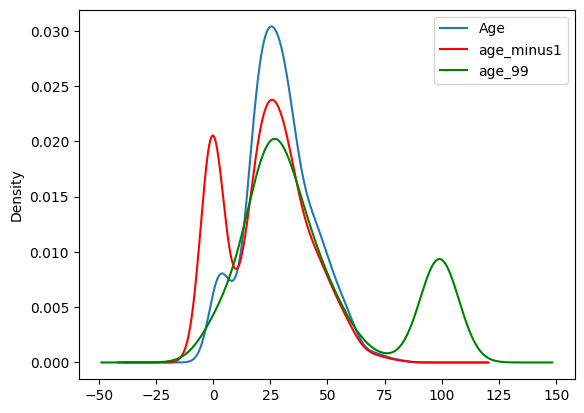

In [18]:
# drawing plot -> Age
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['Age'].plot(kind='kde',ax=ax)

#  age_minus1
x_train['age_minus1'].plot(kind='kde',ax=ax,color='red')

# age_99
x_train['age_99'].plot(kind='kde',ax=ax,color='green')

# add legend
lines,labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

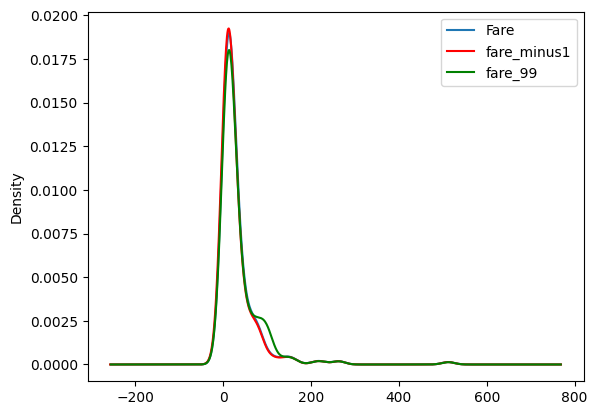

In [19]:
# drawing plot -> Fare
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['Fare'].plot(kind='kde',ax=ax)

#  age_minus1
x_train['fare_minus1'].plot(kind='kde',ax=ax,color='red')

# age_99
x_train['fare_99'].plot(kind='kde',ax=ax,color='green')

# add legend
lines,labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

In [20]:
x_train.cov()

,Age,Fare,Family,age_99,age_minus1,fare_99,fare_minus1
Age,211.951881,71.822073,-6.932603,211.951881,211.951881,75.437530,64.008850
Fare,71.822073,2666.929672,18.612474,-96.618382,123.640954,2666.929672,2666.929672
Family,-6.932603,18.612474,2.997027,-6.494900,-5.140857,17.510303,17.814557
age_99,211.951881,-96.618382,-6.494900,946.397459,-167.251857,-100.661852,-87.710502
age_minus1,211.951881,123.640954,-5.140857,-167.251857,315.874102,130.270133,111.531652
fare_99,75.437530,2666.929672,17.510303,-100.661852,130.270133,2745.627364,2437.111525
fare_minus1,64.008850,2666.929672,17.814557,-87.710502,111.531652,2437.111525,2587.685352


In [21]:
x_train.corr()

,Age,Fare,Family,age_99,age_minus1,fare_99,fare_minus1
Age,1.000000,0.088197,-0.310167,1.000000,1.000000,0.092364,0.080214
Fare,0.088197,1.000000,0.205140,-0.060399,0.134431,1.000000,1.000000
Family,-0.310167,0.205140,1.000000,-0.121952,-0.167083,0.193031,0.202290
age_99,1.000000,-0.060399,-0.121952,1.000000,-0.305898,-0.062446,-0.056048
age_minus1,1.000000,0.134431,-0.167083,-0.305898,1.000000,0.139884,0.123363
fare_99,0.092364,1.000000,0.193031,-0.062446,0.139884,1.000000,0.914321
fare_minus1,0.080214,1.000000,0.202290,-0.056048,0.123363,0.914321,1.000000


# Filling missing values using sklearn 


In [27]:
imputer1 = SimpleImputer(strategy='constant',fill_value=99)
imputer2 = SimpleImputer(strategy='constant',fill_value=999)

In [28]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [29]:
# memorising the parameter
trf.fit(x_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [32]:
trf.named_transformers_['imputer1'].statistics_
# it return the exact value that will fill in the place of the missing value

array([99], dtype=object)

In [33]:
trf.named_transformers_['imputer2'].statistics_

array([999], dtype=object)

In [34]:
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)

In [35]:
x_train

array([[  4.    ,  81.8583,   2.    ],
       [ 99.    ,   7.8958,   0.    ],
       [  1.    ,  11.1333,   2.    ],
       ...,
       [ 41.    , 999.    ,   2.    ],
       [ 14.    , 120.    ,   3.    ],
       [ 21.    ,  77.2875,   1.    ]], shape=(623, 3))

In [36]:
x_test

array([[9.900000e+01, 1.524580e+01, 2.000000e+00],
       [3.100000e+01, 1.050000e+01, 0.000000e+00],
       [2.000000e+01, 7.925000e+00, 0.000000e+00],
       [6.000000e+00, 3.300000e+01, 1.000000e+00],
       [1.400000e+01, 1.124170e+01, 1.000000e+00],
       [2.600000e+01, 7.885000e+01, 0.000000e+00],
       [9.900000e+01, 7.750000e+00, 0.000000e+00],
       [1.600000e+01, 1.800000e+01, 2.000000e+00],
       [1.600000e+01, 7.750000e+00, 0.000000e+00],
       [1.900000e+01, 2.628330e+01, 2.000000e+00],
       [3.700000e+01, 5.310000e+01, 1.000000e+00],
       [4.400000e+01, 8.050000e+00, 0.000000e+00],
       [9.900000e+01, 2.546670e+01, 4.000000e+00],
       [3.000000e+01, 7.225000e+00, 0.000000e+00],
       [3.600000e+01, 1.300000e+01, 0.000000e+00],
       [1.600000e+01, 3.940000e+01, 1.000000e+00],
       [4.200000e+01, 5.255420e+01, 1.000000e+00],
       [9.900000e+01, 7.829200e+00, 0.000000e+00],
       [2.700000e+01, 1.300000e+01, 0.000000e+00],
       [4.700000e+01, 5.200000e